In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
import scipy.stats as stats
np.random.seed(seed=2303)

## Create a dataset

In [2]:
mux0 = 2
mux1 = 4
sigmax = 0.7
N0=10
N1=10

x0 = stats.norm(loc=mux0,scale=sigmax).rvs(N0)
x1 = stats.norm(loc=mux1,scale=sigmax).rvs(N1)

minx = min(min(x0),min(x1))
maxx = max(max(x0),max(x1))

## Statistics

In [3]:
alphahat = N1/(N0+N1)
mu0hat = x0.mean()
mu1hat = x1.mean()
sigmahat = np.sqrt( (N0*x0.var(ddof=1) + N1*x1.var(ddof=1))/(N0+N1) ) 

## Manual solution to logistic regression

In [4]:
theta0hat = np.log(alphahat/(1-alphahat)) + (mu0hat**2-mu1hat**2)/(2*sigmahat**2)
theta1hat = (mu1hat-mu0hat)/(sigmahat**2)

def sigmoid(z):
    return 1/(1+np.exp(-z))

def h1(x):
    return sigmoid(theta0hat+theta1hat*x)

In [5]:
X = np.hstack((x0,x1))
X = X[:,np.newaxis]
y =np.hstack((np.zeros(N0),np.ones(N1)))
logreg = LogisticRegression(random_state=0).fit(X, y)

def h2(x):
    if x.ndim==0:
        phat = logreg.predict_proba(x)
        return phat[1]
    elif x.ndim==1:
        phat = logreg.predict_proba(x[:,np.newaxis])
        return phat[:,1]
    elif x.ndim==2:
        phat = logreg.predict_proba(x)
        return phat[:,1]
    else:
        return None

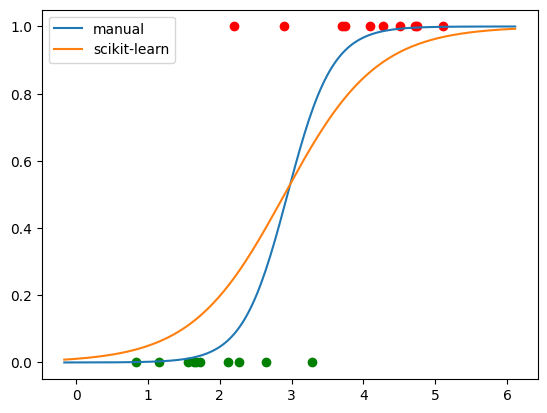

In [6]:
xx = np.linspace(minx-1,maxx+1,200)

fig = plt.figure()
ax = plt.subplot()
ax.plot(x0,np.zeros(N0),linestyle='',marker='o',color='g')
ax.plot(x1,np.ones(N1),linestyle='',marker='o',color='r')
ax.plot(xx,h1(xx),label='manual')
ax.plot(xx,h2(xx),label='scikit-learn')
ax.legend()

# loss of the two models

In [7]:
def CE(y,p):
    return -y*np.log(p)-(1-y)*np.log(1-p)

In [8]:
h1loss = sum(CE(y,h1(X[:,0])))
h2loss = sum(CE(y,h2(X)))

print(f"Loss manual model: {h1loss:.2f}")
print(f"Loss scikitlearn model: {h2loss:.2f}")

Loss manual model: 5.39
Loss scikitlearn model: 5.81
